# Decision Tree Regression 
- CART - CLASSIFICATION AND REGRESSTION TREE

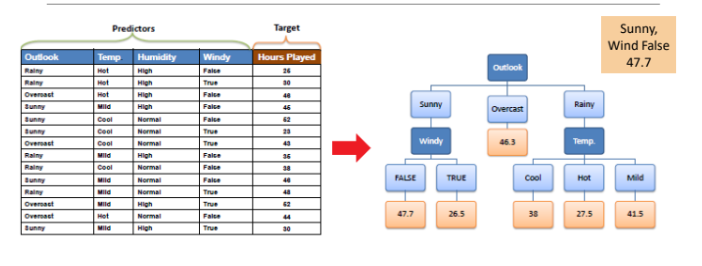

In [1]:
from warnings import filterwarnings

filterwarnings("ignore")

# Step 1- Data Injestion

In [2]:
import pandas as pd

df = pd.read_csv("PowerPlant.csv")

In [7]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


# column names
1. AT = Ambient Temperature in Degree celcius
2. V = vaccum pressure
3. AP = Atomospheric Pressure
4. RH = Relative Humidity (Percentage)
5. PE = Power Output of Plant(MW) - Target

# Step 2 - Basic Data Quality Check

In [14]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(41)

In [16]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)

In [17]:
df.shape

(9527, 5)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9527 non-null   float64
 1   V       9527 non-null   float64
 2   AP      9527 non-null   float64
 3   RH      9527 non-null   float64
 4   PE      9527 non-null   float64
dtypes: float64(5)
memory usage: 372.3 KB


# Step 3 - Separate X and Y

In [3]:
X = df.drop(columns=["PE"])

In [4]:
Y = df[["PE"]]

In [8]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [9]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


# Step 4 - Apply preprocessing on X

In [10]:
X.dtypes

AT    float64
V     float64
AP    float64
RH    float64
dtype: object

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
num_pipe = make_pipeline(
    SimpleImputer(strategy="median"), 
    StandardScaler()).set_output(transform="pandas"
)

In [19]:
X_pre = num_pipe.fit_transform(X)

In [20]:
X_pre.head()

,AT,V,AP,RH
0,-1.517862,-1.065205,-0.407357,1.143944
1,0.535255,0.329277,-0.313057,0.061031
2,1.353818,0.204151,-1.028729,-2.150688
3,-0.077996,-0.363242,-1.016941,0.238434
4,-1.053562,-1.073861,0.651838,1.636427


In [21]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


# Step 5 - Apply Train Test Split

In [22]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    X_pre, Y, test_size=0.2, random_state=42
)

In [23]:
xtrain.head()

,AT,V,AP,RH
5487,0.749961,0.721180,-0.329896,-0.486248
3522,0.864023,1.266539,-0.984946,0.826125
6916,0.936486,1.524659,0.318419,0.809686
7544,1.665141,1.380647,-0.902434,-1.155449
7600,1.214260,1.364121,-1.035464,-0.236924


In [24]:
ytrain.head()

,PE
5487,442.75
3522,432.52
6916,428.80
7544,426.07
7600,436.58


In [25]:
ytest.head()

,PE
2513,433.27
9411,438.16
8745,458.42
9085,480.82
4950,441.41


In [26]:
xtest.head()

,AT,V,AP,RH
2513,1.348451,0.239564,-1.284687,-1.093118
9411,0.813030,1.364121,-0.742460,0.274052
8745,-0.244392,-0.738619,1.983830,-0.186923
9085,-1.367568,-1.015627,2.276835,0.977500
4950,1.375289,0.825058,0.613107,-1.717111


In [28]:
xtrain.shape

(7654, 4)

In [29]:
xtest.shape

(1914, 4)

# Step 6 - Model Building

In [37]:
from sklearn.tree import DecisionTreeRegressor

model1 = DecisionTreeRegressor(
    max_depth=1,
    min_samples_split=5,
    min_samples_leaf=5,
    criterion="squared_error",
    random_state=42,
)
model1.fit(xtrain, ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [38]:
model1.score(xtrain, ytrain)

0.7198747894940933

In [39]:
model1.score(xtest, ytest)

0.7216705971501842

### Hyperparameter tuning

In [43]:
params = {
    "max_depth": [8, 9, 10, 11, 12, 13],
    "min_samples_split": [5, 6, 7, 8],
    "min_samples_leaf": [5, 6, 7, 8],
    "criterion": ["squared_error", "absolute_error"],
}

In [44]:
from sklearn.model_selection import RandomizedSearchCV

In [45]:
dtr = DecisionTreeRegressor(random_state=42)
rscv_dtr = RandomizedSearchCV(
    dtr, param_distributions=params, cv=5, scoring="r2", random_state=42
)
rscv_dtr.fit(xtrain, ytrain)

,estimator,DecisionTreeR...ndom_state=42)
,param_distributions,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [8, 9, ...], 'min_samples_leaf': [5, 6, ...], 'min_samples_split': [5, 6, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [46]:
rscv_dtr.best_params_

{'min_samples_split': 7,
 'min_samples_leaf': 5,
 'max_depth': 9,
 'criterion': 'squared_error'}

In [48]:
rscv_dtr.best_score_

np.float64(0.9425684573014605)

In [49]:
best_dtr = rscv_dtr.best_estimator_
best_dtr

,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,7
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


# Step 8 - Model evaluation

In [50]:
best_dtr.score(xtrain, ytrain)

0.9628804925109674

In [51]:
best_dtr.score(xtest, ytest)

0.9463766718102076

In [52]:
from sklearn.metrics import (
    root_mean_squared_error,
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

In [55]:
def eval_model(model, x, y):
    ypred = model.predict(x)
    rmse = root_mean_squared_error(y, ypred)
    mae = mean_absolute_error(y, ypred)
    mape = mean_absolute_percentage_error(y, ypred)
    r2 = r2_score(y, ypred)

    print(f"MAE: {mae: .2f}")
    print(f"RMSE: {rmse: .2f}")
    print(f"MAPE: {mape: .2%}")
    print(f"rR2: {r2:.2%}")

In [56]:
print("train results: ")
eval_model(best_dtr, xtrain, ytrain)

train results: 
MAE:  2.44
RMSE:  3.30
MAPE:  0.54%
rR2: 96.29%


In [57]:
print("Test Results")
eval_model(best_dtr, xtest, ytest)

Test Results
MAE:  2.90
RMSE:  3.92
MAPE:  0.64%
rR2: 94.64%


# From above result i can say that this model is good and can be used for out of sample prediction 
R2 >0.8 IN BOTH TRAIN TESTS

In [58]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

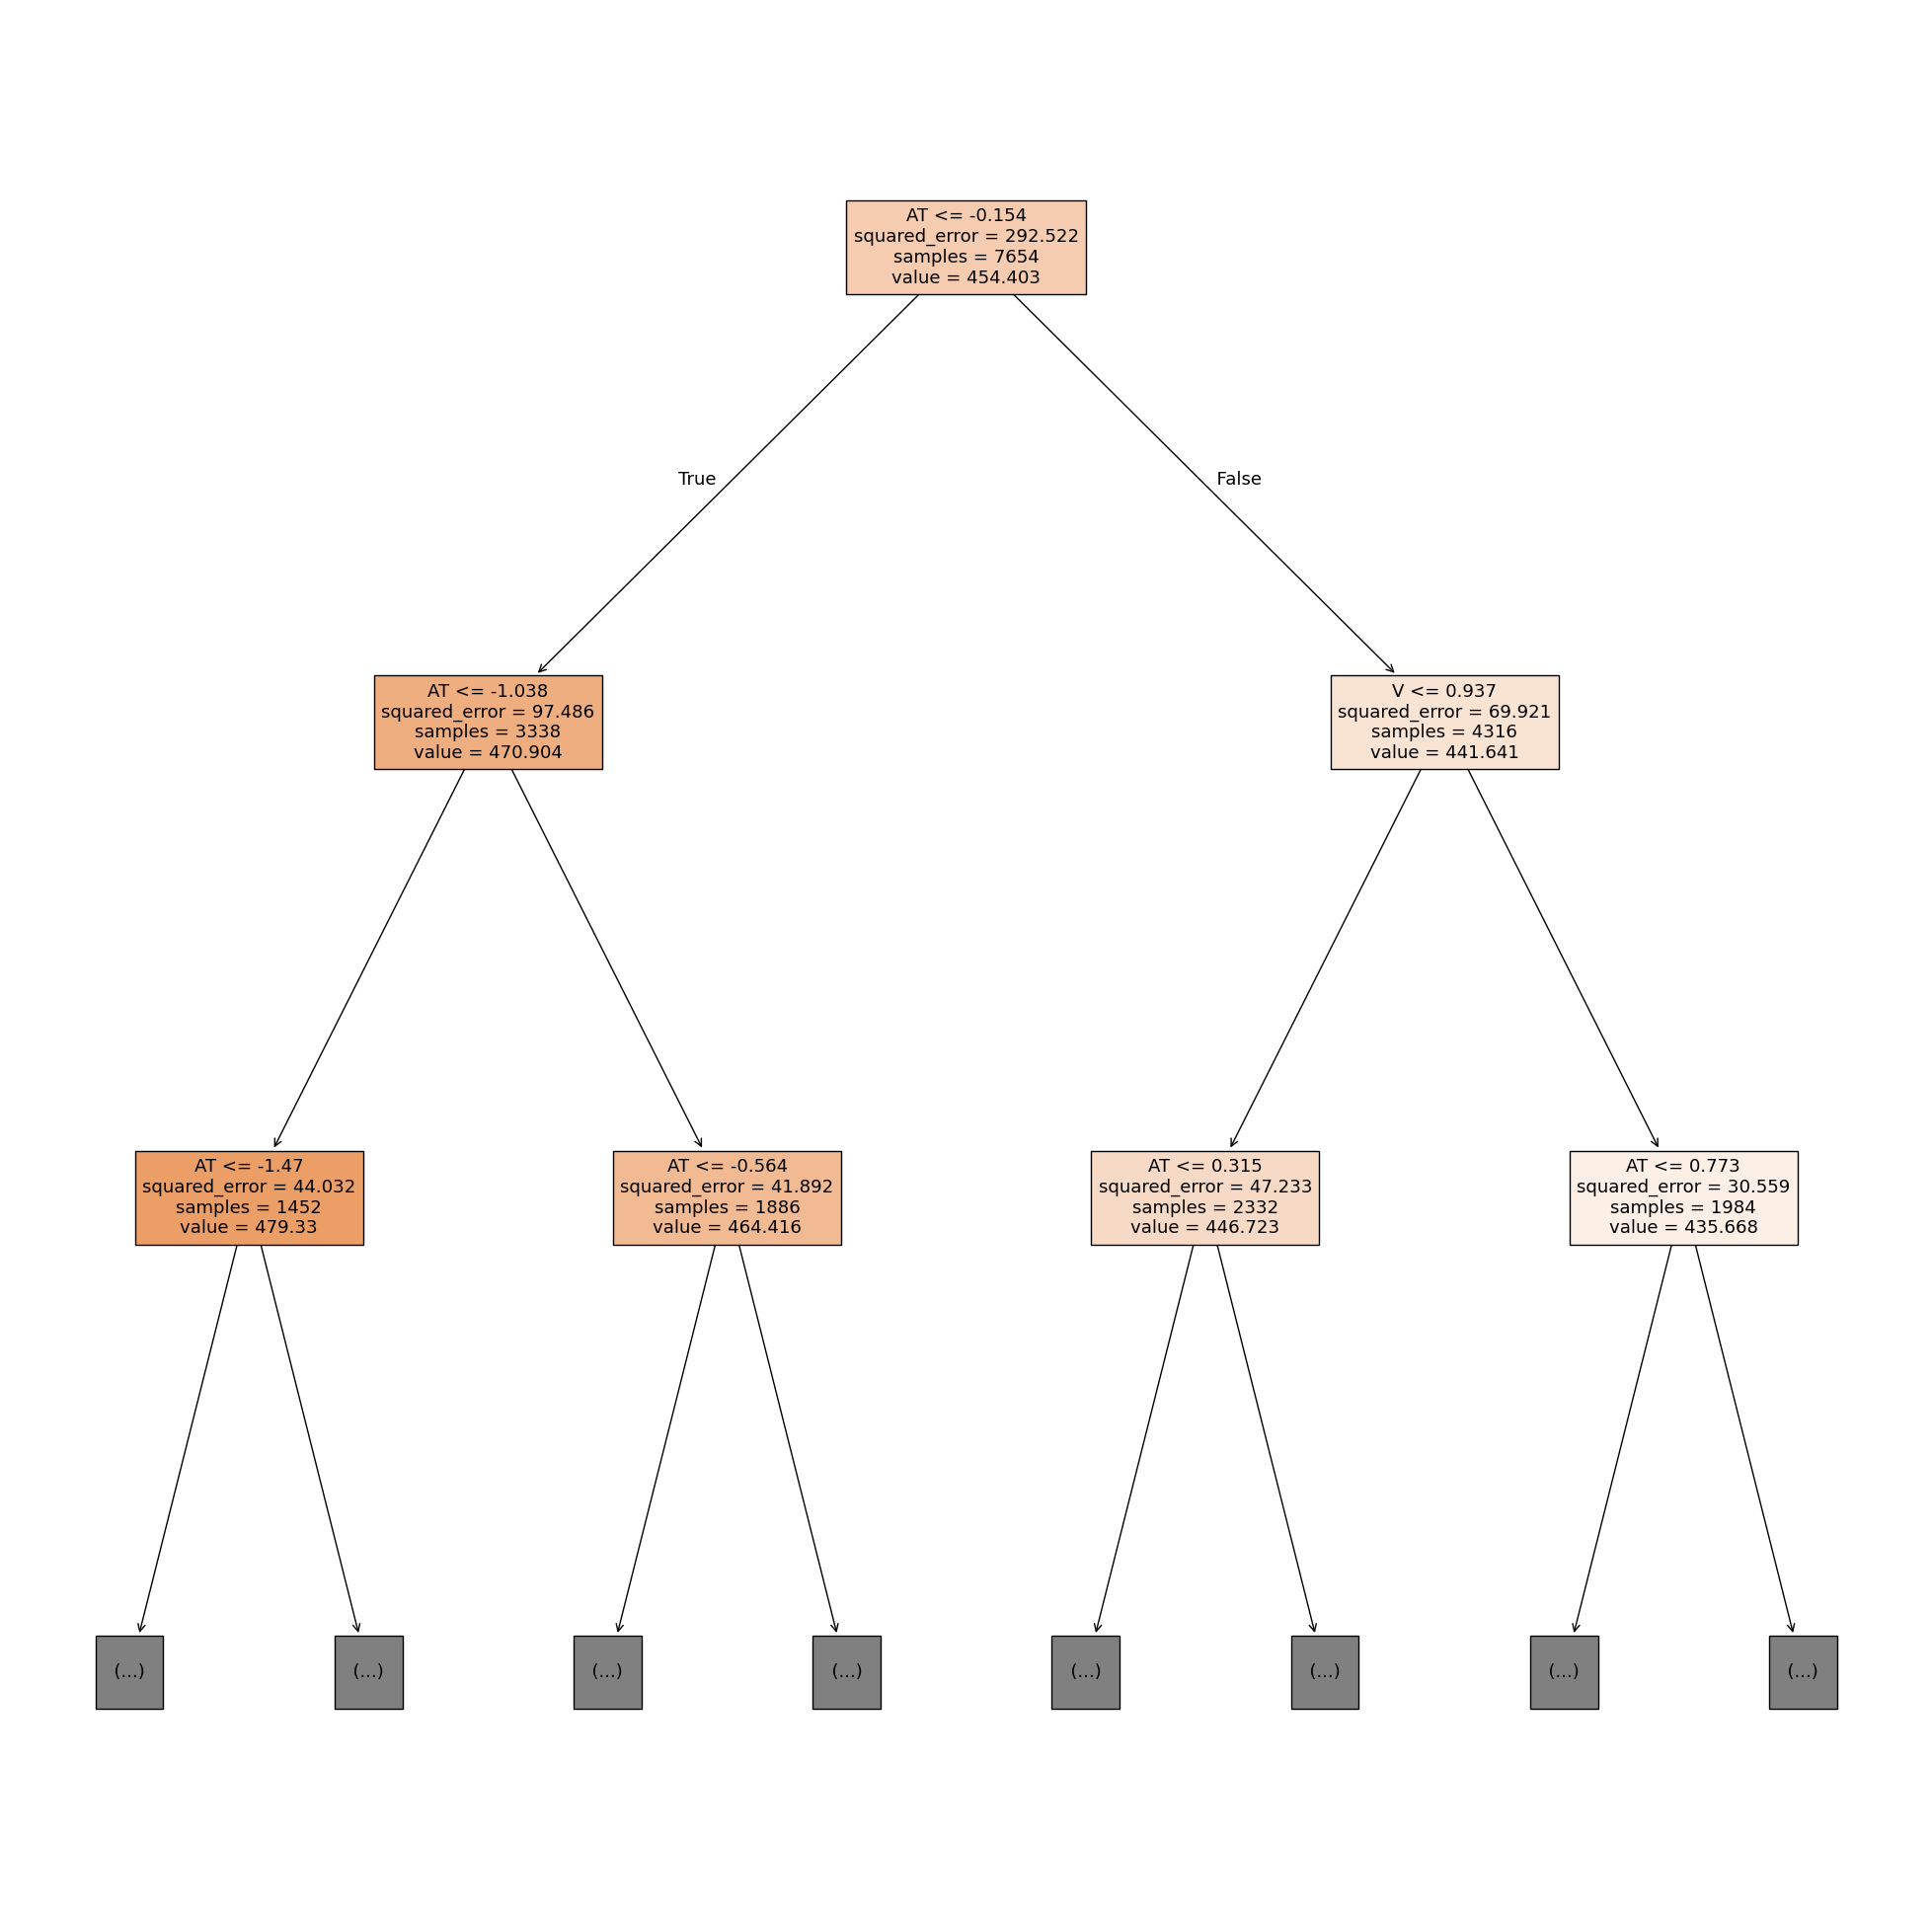

In [63]:
plt.figure(figsize=(25, 25))
plot_tree(best_dtr, feature_names=xtrain.columns, filled=True, max_depth=2)
plt.show()

# Feature Importances

In [64]:
imp = best_dtr.feature_importances_
imp

array([0.89917997, 0.08147654, 0.01145502, 0.00788846])

In [65]:
xtrain.columns

Index(['AT', 'V', 'AP', 'RH'], dtype='object')

In [67]:
feat_imp = pd.Series(imp, index=xtrain.columns).sort_values(ascending=False).round(4)
feat_imp

AT    0.8992
V     0.0815
AP    0.0115
RH    0.0079
dtype: float64

<Axes: title={'center': 'Feature Importances'}>

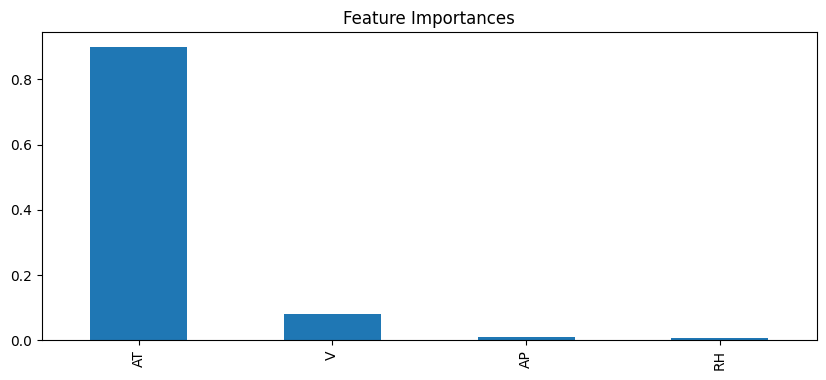

In [69]:
feat_imp.plot(kind="bar", title="Feature Importances", figsize=(10, 4))

# Step 9 - Out of Sample Prediction

In [70]:
xnew = pd.read_csv("test_PowerPlant.csv")
xnew.head()

,AT,V,AP,RH
0,22.49,58.82,1009.73,85.19
1,28.88,54.89,1007.16,46.60
2,27.89,73.21,1001.32,85.88
3,25.69,62.26,1011.38,74.08
4,12.16,40.81,1025.79,70.97


In [72]:
xnew.shape

(100, 4)

In [73]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [74]:
xnew_pre = num_pipe.transform(xnew)
xnew_pre.head()

,AT,V,AP,RH
0,0.380936,0.355246,-0.594274,0.813796
1,1.238415,0.045974,-1.027045,-1.829444
2,1.105566,1.487673,-2.010463,0.861058
3,0.810346,0.625958,-0.316424,0.052812
4,-1.005253,-1.062057,2.110125,-0.160209


In [75]:
preds = best_dtr.predict(xnew_pre)
preds[0:5]

array([444.23333333, 437.68576923, 431.46864407, 441.95486239,
       471.948     ])

In [78]:
xnew["PE_prediced"] = preds.round(1)

In [79]:
xnew

,AT,V,AP,RH,PE_prediced
0,22.49,58.82,1009.73,85.19,444.2
1,28.88,54.89,1007.16,46.60,437.7
2,27.89,73.21,1001.32,85.88,431.5
3,25.69,62.26,1011.38,74.08,442.0
4,12.16,40.81,1025.79,70.97,471.9
...,...,...,...,...,...
95,26.35,69.48,1008.45,70.47,437.5
96,11.78,39.96,1011.37,82.95,474.1
97,5.62,41.38,1020.91,86.21,490.0
98,24.96,74.99,1008.25,80.52,438.8


In [82]:
xnew.to_csv("dtr_results.csv", index=False)

In [80]:
import seaborn as sns

<Axes: xlabel='PE_prediced', ylabel='Count'>

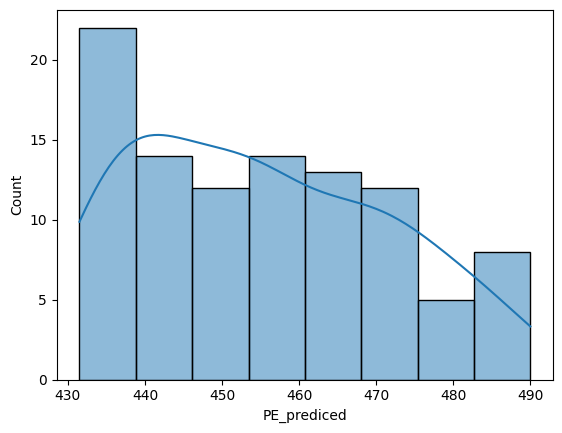

In [81]:
sns.histplot(data=xnew, x="PE_prediced", kde=True)

# Step 10 - Save the preprocessor and model object

In [83]:
import joblib

In [84]:
joblib.dump(num_pipe, "preprocessor.joblib")

['preprocessor.joblib']

In [86]:
joblib.dump(best_dtr, "dtr_model.joblib")

['dtr_model.joblib']

# Load the model object

In [87]:
p = joblib.load("preprocessor.joblib")

In [88]:
p

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [89]:
dtr = joblib.load("dtr_model.joblib")
dtr

,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,7
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0
